# Backpropagation in a Simple MLP

This notebook demonstrates how to compute gradients by hand (using NumPy) and then how to obtain the same gradients automatically with PyTorch's `autograd`. We'll start with a toy example, then apply the same steps to a binary classification task on the Iris dataset.


### 1.1 Problem Setup

- **Input dimension**: 2
- **Hidden layer size**: 2
- **Output dimension**: 1
- **Activation**: Sigmoid
- **Loss**: Mean Squared Error (MSE)

We use the sigmoid activation:

$$
\sigma(z) = \frac{1}{1 + e^{-z}},
\quad
\sigma'(z) = \sigma(z)\bigl(1 - \sigma(z)\bigr).
$$

The loss remains:

$$
L = \frac{1}{2}(y - \hat y)^2.
$$

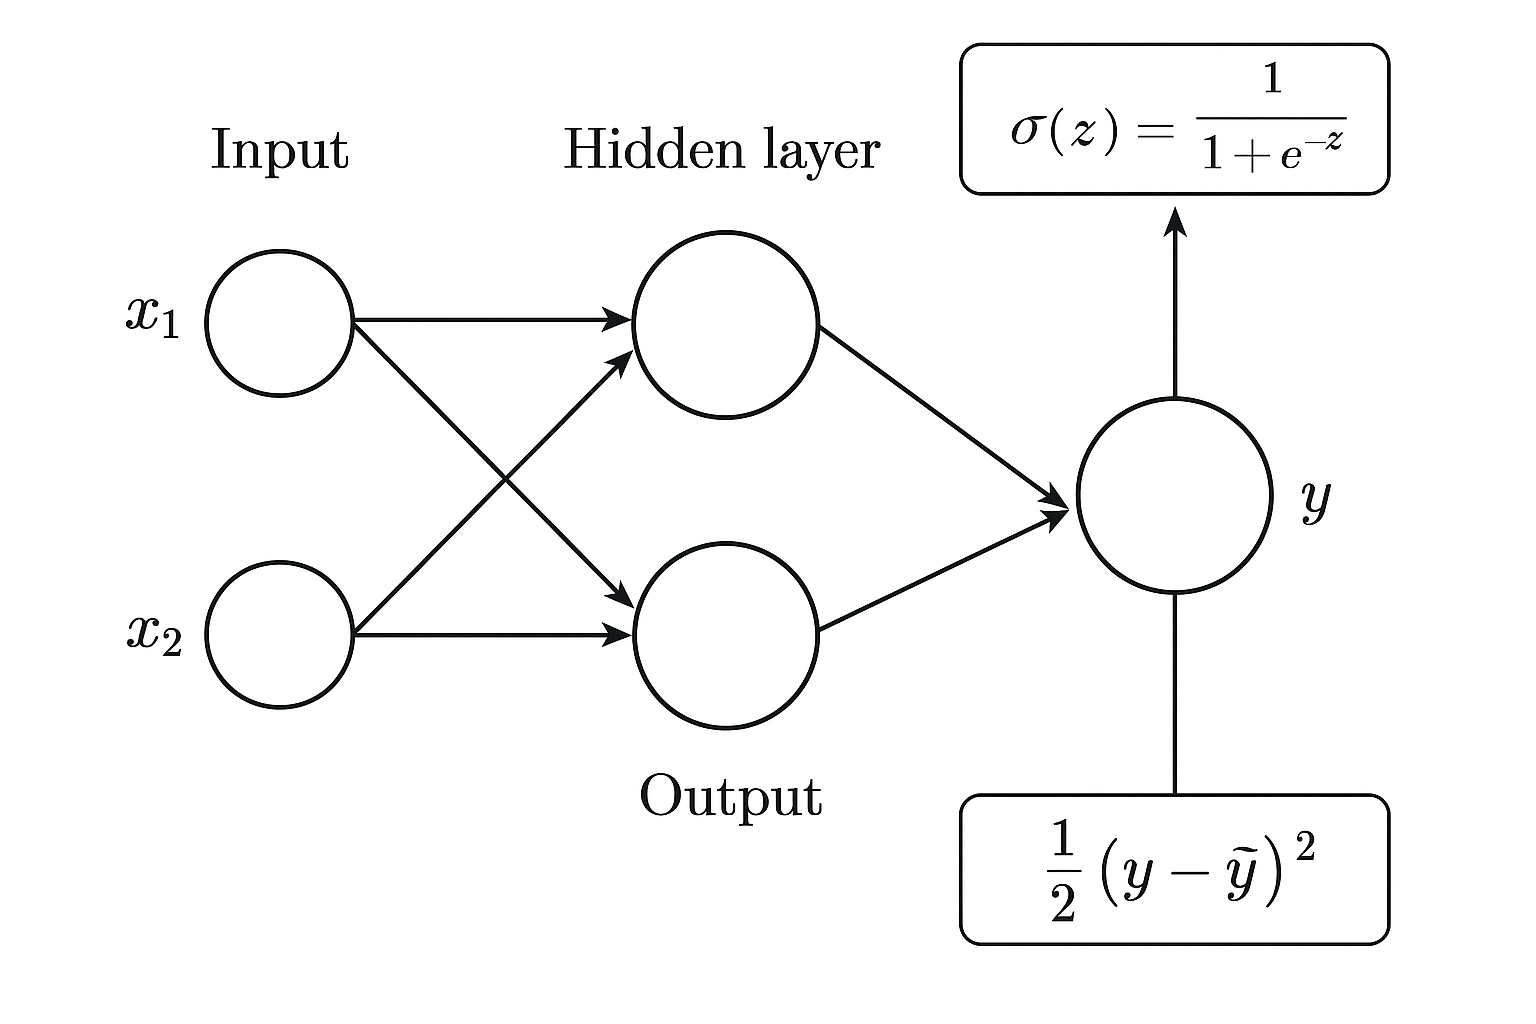

### 1.2 Forward and Backward by Hand (NumPy)

In [1]:
import numpy as np

# Sigmoid & its derivative
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_prime(a):
    return a * (1 - a)

In [2]:
# Toy data
x = np.array([0.6, -1.2])
y = np.array([0.5])

# Initialize parameters
W1 = np.array([[0.1, -0.2],
               [0.3,  0.4]])
b1 = np.zeros(2)
W2 = np.array([[0.2, -0.3]])
b2 = np.zeros(1)

In [3]:
# Forward
z1 = W1 @ x + b1           # shape (2,)
a1 = sigmoid(z1)              # shape (2,)
z2 = W2.dot(a1) + b2          # shape (1,)
y_hat = z2                    # identity output
loss = 0.5 * (y_hat - y)**2   # MSE

In [5]:
# Backward
dL_dyhat = y_hat - y               # shape (1,)
dL_dz2   = dL_dyhat                # since y_hat = z2

dW2 = dL_dz2 * a1                  # shape (1,2)
db2 = dL_dz2                       # shape (1,)

dL_da1  = W2.T * dL_dz2            # shape (2,)
dL_dz1  = dL_da1 * sigmoid_prime(a1)  # shape (2,)

dW1 = np.outer(dL_dz1, x)          # shape (2,2)
db1 = dL_dz1                       # shape (2,)

print("Hand gradients:")
print("dW1:", dW1)
print("db1:", db1)
print("dW2:", dW2)
print("db2:", db2)

Hand gradients:
dW1: [[-0.01504236  0.03008473]
 [-0.01504236  0.03008473]
 [ 0.02256354 -0.04512709]
 [ 0.02256354 -0.04512709]]
db1: [[-0.02507061 -0.02507061]
 [ 0.03760591  0.03760591]]
dW2: [-0.29456191 -0.21821683]
db2: [-0.51277874]


### 1.3 Automatic Gradients (PyTorch)

In [8]:
import torch

# Data & parameters
x_t  = torch.tensor([0.6, -1.2], dtype=torch.float32)
y_t  = torch.tensor([0.5],      dtype=torch.float32)
W1_t = torch.tensor([[0.1, -0.2],
                     [0.3,  0.4]], requires_grad=True)
b1_t = torch.zeros(2, requires_grad=True)
W2_t = torch.tensor([[0.2, -0.3]], requires_grad=True)
b2_t = torch.zeros(1, requires_grad=True)

# Forward & loss
a1_t   = torch.sigmoid(W1_t.matmul(x_t) + b1_t)
y_hat_t= W2_t.matmul(a1_t) + b2_t
loss_t = 0.5 * (y_hat_t - y_t).pow(2)

# Backward
grads = torch.autograd.grad(loss_t, [W1_t, b1_t, W2_t, b2_t])

print("PyTorch gradients:")
print("dW1_t:", grads[0])
print("db1_t:", grads[1])
print("dW2_t:", grads[2])
print("db2_t:", grads[3])

PyTorch gradients:
dW1_t: tensor([[-0.0150,  0.0301],
        [ 0.0226, -0.0451]])
db1_t: tensor([-0.0251,  0.0376])
dW2_t: tensor([[-0.2946, -0.2182]])
db2_t: tensor([-0.5128])


## 2. Iris Dataset: Binary Classification (Setosa vs Versicolor)

In this section we use Fisher's Iris dataset, a classic in machine learning:

- **Samples**: 150 total; we select 100 samples of two classes (Setosa and Versicolor).
- **Features**: 4 numeric measurements per flower: sepal length, sepal width, petal length, and petal width.
- **Classes**: Originally three species (Setosa, Versicolor, Virginica), but we simplify to a binary task by selecting only Setosa (label 0) and Versicolor (label 1).

The goal is to train a simple MLP to distinguish between these two species based on their measurements.


## Loss Function: Binary Cross-Entropy

For our binary (Setosa vs. Versicolor) classification, we use the **binary cross-entropy** (BCE) loss.  BCE measures the dissimilarity between the true labels $y\in\{0,1\}$ and the predicted probabilities $\hat y\in(0,1)$.  It is defined for a single example as:

$$
L(y, \hat y) \;=\; -\Bigl[y\log(\hat y)\;+\;(1 - y)\log(1 - \hat y)\Bigr].
$$

- If $y=1$, the loss reduces to $-\log(\hat y)$, which penalizes $\hat y$ being far below 1.  
- If $y=0$, the loss is $-\log(1-\hat y)$, which penalizes $\hat y$ being far above 0.  

A perfect prediction $(\hat y=y$) yields zero loss; bad predictions incur large penalties.

When training over a batch of \(N\) examples, we typically take the average:

$$
L_{\mathrm{batch}} \;=\; \frac{1}{N}\sum_{i=1}^N \;-\Bigl[y^{(i)}\log(\hat y^{(i)}) + (1 - y^{(i)})\log(1 - \hat y^{(i)})\Bigr].
$$



### 2.1 Load & Preprocess

In [9]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

iris = load_iris()
X = iris.data[iris.target < 2]               # select setosa & versicolor
y = iris.target[iris.target < 2].reshape(-1,1)  # labels 0 or 1

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# standardize
scaler      = StandardScaler().fit(X_train)
X_train_std = scaler.transform(X_train)
X_test_std  = scaler.transform(X_test)

### 2.2 NumPy MLP Forward & Backward

In [12]:
# Network dimensions
dim_in, dim_h1, dim_h2, dim_out = 4, 5, 3, 1

# Initialize parameters
rng = np.random.RandomState(0)
W1 = rng.randn(dim_h1, dim_in) * 0.1
b1 = np.zeros(dim_h1)
W2 = rng.randn(dim_h2, dim_h1) * 0.1
b2 = np.zeros(dim_h2)
W3 = rng.randn(dim_out, dim_h2) * 0.1
b3 = np.zeros(dim_out)

In [15]:
def forward_backward(x, y_true):
    # Forward pass
    z1 = W1.dot(x) + b1            # → (dim_h1,)
    a1 = sigmoid(z1)               # → (dim_h1,)
    z2 = W2.dot(a1) + b2           # → (dim_h2,)
    a2 = sigmoid(z2)               # → (dim_h2,)
    z3 = W3.dot(a2) + b3           # → (1,)
    y_pred = sigmoid(z3)           # → (1,)

    # Loss (binary cross-entropy)
    loss = - (y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    # Backward pass
    dL_dz3 = y_pred - y_true                         # (1,)
    dW3 = np.outer(dL_dz3, a2)                       # (1, dim_h2)
    db3 = dL_dz3                                     # (1,)

    dL_da2 = W3.T.dot(dL_dz3)                        # (dim_h2,)
    dL_dz2 = dL_da2 * sigmoid_prime(a2)              # (dim_h2,)
    dW2 = np.outer(dL_dz2, a1)                       # (dim_h2, dim_h1)
    db2 = dL_dz2                                     # (dim_h2,)

    dL_da1 = W2.T.dot(dL_dz2)                        # (dim_h1,)
    dL_dz1 = dL_da1 * sigmoid_prime(a1)              # (dim_h1,)
    dW1 = np.outer(dL_dz1, x)                        # (dim_h1, dim_in)
    db1 = dL_dz1                                     # (dim_h1,)

    return loss, dW1, db1, dW2, db2, dW3, db3

# Test on one training example
i = 0
loss_np, dW1_np, db1_np, dW2_np, db2_np, dW3_np, db3_np = forward_backward(
    X_train_std[i], y_train[i]
)

print("NumPy gradient shapes:",
      "\ndW1:", dW1_np.shape,
      "\ndb1:", db1_np.shape,
      "\ndW2:", dW2_np.shape,
      "\ndb2:", db2_np.shape,
      "\ndW3:", dW3_np.shape,
      "\ndb3:", db3_np.shape)

NumPy gradient shapes: 
dW1: (5, 4) 
db1: (5,) 
dW2: (3, 5) 
db2: (3,) 
dW3: (1, 3) 
db3: (1,)


In [16]:
# PyTorch implementation: Two-hidden-layer MLP + autograd

import torch
import torch.nn as nn

# Data to tensors
torch.manual_seed(0)
X_t = torch.tensor(X_train_std, dtype=torch.float32)
y_t = torch.tensor(y_train,     dtype=torch.float32)

# Model with two hidden layers
model = nn.Sequential(
    nn.Linear(dim_in, dim_h1),
    nn.Sigmoid(),
    nn.Linear(dim_h1, dim_h2),
    nn.Sigmoid(),
    nn.Linear(dim_h2, dim_out),
    nn.Sigmoid()
)
criterion = nn.BCELoss()

# Forward + backward on one sample
i = 0
model.zero_grad()
print("\nPyTorch implementation: Two-hidden-layer MLP + autograd")
out = model(X_t[i:i+1])               # (1, 1)
loss_t = criterion(out, y_t[i:i+1])
loss_t.backward()

# Inspect gradients
grad_W1 = model[0].weight.grad       # (dim_h1, dim_in)
grad_b1 = model[0].bias.grad         # (dim_h1,)
grad_W2 = model[2].weight.grad       # (dim_h2, dim_h1)
grad_b2 = model[2].bias.grad         # (dim_h2,)
grad_W3 = model[4].weight.grad       # (dim_out, dim_h2)
grad_b3 = model[4].bias.grad         # (dim_out,)

print("PyTorch gradient shapes:",
      "\ngrad_W1:", grad_W1.shape,
      "\ngrad_b1:", grad_b1.shape,
      "\ngrad_W2:", grad_W2.shape,
      "\ngrad_b2:", grad_b2.shape,
      "\ngrad_W3:", grad_W3.shape,
      "\ngrad_b3:", grad_b3.shape)


PyTorch implementation: Two-hidden-layer MLP + autograd
PyTorch gradient shapes: 
grad_W1: torch.Size([5, 4]) 
grad_b1: torch.Size([5]) 
grad_W2: torch.Size([3, 5]) 
grad_b2: torch.Size([3]) 
grad_W3: torch.Size([1, 3]) 
grad_b3: torch.Size([1])


## 3. Training

Run both implementations on the same example;

### 3.1 NumPy Training Loop

In [25]:
num_epochs = 500
lr = 0.1

In [26]:
for epoch in range(num_epochs):
    # Accumulate gradients over all training samples
    sum_dW1 = np.zeros_like(W1)
    sum_db1 = np.zeros_like(b1)
    sum_dW2 = np.zeros_like(W2)
    sum_db2 = np.zeros_like(b2)
    sum_dW3 = np.zeros_like(W3)
    sum_db3 = np.zeros_like(b3)
    total_loss = 0.0

    for x_vec, y_val in zip(X_train_std, y_train):
        loss, dW1, db1, dW2, db2, dW3, db3 = forward_backward(x_vec, y_val)
        total_loss += loss
        sum_dW1 += dW1
        sum_db1 += db1
        sum_dW2 += dW2
        sum_db2 += db2
        sum_dW3 += dW3
        sum_db3 += db3

    # Average gradients and loss
    N = X_train_std.shape[0]
    avg_dW1, avg_db1 = sum_dW1/N, sum_db1/N
    avg_dW2, avg_db2 = sum_dW2/N, sum_db2/N
    avg_dW3, avg_db3 = sum_dW3/N, sum_db3/N
    avg_loss = total_loss / N
    avg_loss = avg_loss[0]

    # Gradient descent update
    W1 -= lr * avg_dW1
    b1 -= lr * avg_db1
    W2 -= lr * avg_dW2
    b2 -= lr * avg_db2
    W3 -= lr * avg_dW3
    b3 -= lr * avg_db3

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1:2d}, avg loss = {avg_loss:.4f}")

Epoch 10, avg loss = 0.6923
Epoch 20, avg loss = 0.6923
Epoch 30, avg loss = 0.6923
Epoch 40, avg loss = 0.6923
Epoch 50, avg loss = 0.6923
Epoch 60, avg loss = 0.6923
Epoch 70, avg loss = 0.6923
Epoch 80, avg loss = 0.6922
Epoch 90, avg loss = 0.6922
Epoch 100, avg loss = 0.6922
Epoch 110, avg loss = 0.6922
Epoch 120, avg loss = 0.6922
Epoch 130, avg loss = 0.6922
Epoch 140, avg loss = 0.6922
Epoch 150, avg loss = 0.6922
Epoch 160, avg loss = 0.6921
Epoch 170, avg loss = 0.6921
Epoch 180, avg loss = 0.6921
Epoch 190, avg loss = 0.6921
Epoch 200, avg loss = 0.6921
Epoch 210, avg loss = 0.6921
Epoch 220, avg loss = 0.6921
Epoch 230, avg loss = 0.6920
Epoch 240, avg loss = 0.6920
Epoch 250, avg loss = 0.6920
Epoch 260, avg loss = 0.6920
Epoch 270, avg loss = 0.6920
Epoch 280, avg loss = 0.6919
Epoch 290, avg loss = 0.6919
Epoch 300, avg loss = 0.6919
Epoch 310, avg loss = 0.6919
Epoch 320, avg loss = 0.6919
Epoch 330, avg loss = 0.6918
Epoch 340, avg loss = 0.6918
Epoch 350, avg loss = 0

### 3.2 PyTorch Training Loop

In [ ]:
import torch
import torch.nn as nn

# Re‐build model
model = nn.Sequential(
    nn.Linear(dim_in, dim_h1),
    nn.Sigmoid(),
    nn.Linear(dim_h1, dim_h2),
    nn.Sigmoid(),
    nn.Linear(dim_h2, dim_out),
    nn.Sigmoid()
)
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

X_t = torch.tensor(X_train_std, dtype=torch.float32)
y_t = torch.tensor(y_train,     dtype=torch.float32)

for epoch in range(num_epochs):
    optimizer.zero_grad()
    out = model(X_t)                  # (N, 1)
    loss = criterion(out, y_t)        # mean over batch
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1:2d}, loss = {loss.item():.4f}")

Epoch 10, loss = 0.7173
Epoch 20, loss = 0.7038
Epoch 30, loss = 0.6979
Epoch 40, loss = 0.6953
Epoch 50, loss = 0.6941
Epoch 60, loss = 0.6935
Epoch 70, loss = 0.6932
Epoch 80, loss = 0.6930
Epoch 90, loss = 0.6929
Epoch 100, loss = 0.6927
Epoch 110, loss = 0.6926
Epoch 120, loss = 0.6925
Epoch 130, loss = 0.6924
Epoch 140, loss = 0.6923
Epoch 150, loss = 0.6923
Epoch 160, loss = 0.6922
Epoch 170, loss = 0.6921
Epoch 180, loss = 0.6920
Epoch 190, loss = 0.6919
Epoch 200, loss = 0.6918
Epoch 210, loss = 0.6917
Epoch 220, loss = 0.6916
Epoch 230, loss = 0.6915
Epoch 240, loss = 0.6915
Epoch 250, loss = 0.6914
Epoch 260, loss = 0.6913
Epoch 270, loss = 0.6912
Epoch 280, loss = 0.6910
Epoch 290, loss = 0.6909
Epoch 300, loss = 0.6908
Epoch 310, loss = 0.6907
Epoch 320, loss = 0.6906
Epoch 330, loss = 0.6904
Epoch 340, loss = 0.6903
Epoch 350, loss = 0.6901
Epoch 360, loss = 0.6900
Epoch 370, loss = 0.6898
Epoch 380, loss = 0.6896
Epoch 390, loss = 0.6894
Epoch 400, loss = 0.6892
Epoch 410